In [5]:
# Import required libraries
import pandas as pd
import zipfile
import matplotlib.pyplot as plt


In [24]:
# 1. Load Dataset from ZIP file

with zipfile.ZipFile(r"C:\Users\nisha\Downloads\student.zip", "r") as z:
    with z.open("student-mat.csv") as f:
        df = pd.read_csv(f, sep=";")

print("Dataset loaded successfully")
print(df.head())


Dataset loaded successfully
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


In [21]:
# 2. Explore & Clean Data

#Checked for missing values using .isnull().sum()

#Removed duplicate records to avoid biased results

#Inspected the shape of the dataset (rows and columns)

#Examined data types of each column to understand variable formats


# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Dataset shape
print("\nDataset shape:", df.shape)

# Data types
print("\nData types:")
print(df.dtypes)


Missing values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Dataset shape: (395, 33)

Data types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nurse

In [25]:
# 3. Analysis Questions

#Calculated the average final grade (G3) to understand overall performance

#Counted the number of students scoring above 15, indicating high performance

#Analyzed the correlation between study time and final grades to see if more study time improves results

#Compared average performance by gender to identify differences

# Average final grade (G3)
avg_g3 = df['G3'].mean()
print("Average Final Grade (G3):", round(avg_g3, 2))


# Students scoring above 15
above_15 = df[df['G3'] > 15].shape[0]
print("Students scoring above 15:", above_15)


# Correlation between study time and performance
correlation = df['studytime'].corr(df['G3'])
print("Correlation between study time and final grade:", round(correlation, 2))


# Gender-wise performance
gender_avg = df.groupby('sex')['G3'].mean()
print("\nAverage grade by gender:")
print(gender_avg)


Average Final Grade (G3): 10.42
Students scoring above 15: 40
Correlation between study time and final grade: 0.1

Average grade by gender:
sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


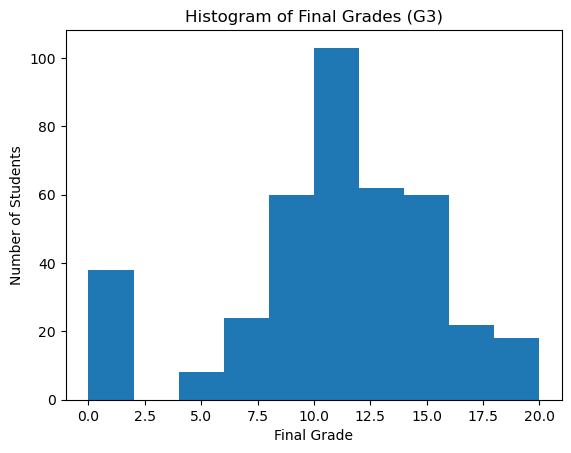

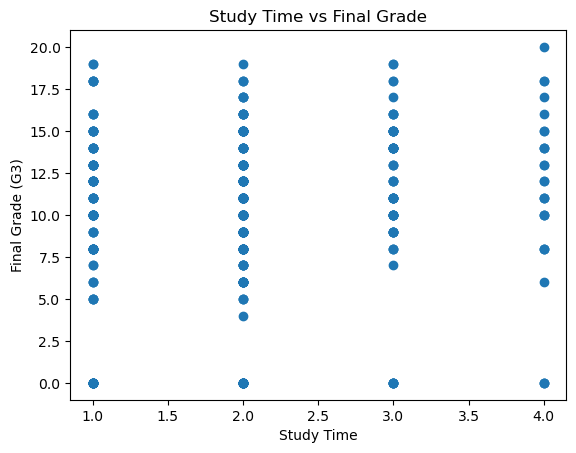

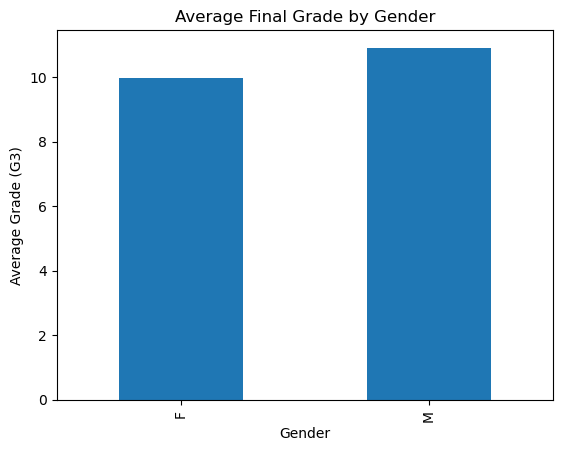

In [23]:
# 4. Visualizations

#Histogram of final grades (G3) to show grade distribution

#Scatter plot of study time vs final grades to visualize their relationship

#Bar chart comparing male and female average scores to show gender-based performance

# Histogram of grades
plt.figure()
plt.hist(df['G3'], bins=10)
plt.title("Histogram of Final Grades (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.show()

# Scatter plot: Study time vs grades
plt.figure()
plt.scatter(df['studytime'], df['G3'])
plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")
plt.show()

# Bar chart: Male vs Female average score
plt.figure()
gender_avg.plot(kind='bar')
plt.title("Average Final Grade by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Grade (G3)")
plt.show()
